# San Francisco Police Incident Analysis: PySpark and Count Modeling

This project analyzes San Francisco Police Department incident reports using PySpark and Spark SQL, with an emphasis on reproducible data processing, record-level validation, temporal and geographic patterns, and statistical modeling of reported incident counts.

**Data source:** DataSF, Police Department Incident Reports: 2018 to Present  
**Data snapshot:** July 22, 2026  
**Primary analysis period:** January 1, 2018 – December 31, 2025

## 1. Data Ingestion and Validation

### 1.1 Environment and Data Loading

In [1]:
import os
from pathlib import Path

os.environ["JAVA_HOME"] = "/opt/homebrew/opt/openjdk@17"
os.environ["PATH"] = os.environ["JAVA_HOME"] + "/bin:" + os.environ["PATH"]

In [2]:
DATA_PATH = Path("sfpd_incidents_2018_present_2026-07-22.csv")

if not DATA_PATH.exists():
    raise FileNotFoundError(f"Dataset not found: {DATA_PATH}")

In [ ]:
from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .master("local[*]")
    .appName("sfpd_incident_analysis")
    .config(
        "spark.sql.session.timeZone",
        "America/Los_Angeles"
    )
    .config(
        "spark.ui.showConsoleProgress",
        "false"
    )
    .getOrCreate()
)

spark.sparkContext.setLogLevel("ERROR")

In [4]:
df_raw = (
    spark.read
    .option("header", "true")
    .csv(str(DATA_PATH))
)

print(f"Rows: {df_raw.count():,}")
print(f"Columns: {len(df_raw.columns)}")

df_raw.printSchema()

df_raw.select(
    "Row ID",
    "Incident Datetime",
    "Incident ID",
    "Report Type Description",
    "Incident Code",
    "Incident Category",
    "Police District"
).show(5, truncate=False)

Rows: 1,048,600
Columns: 29
root
 |-- Row ID: string (nullable = true)
 |-- Incident Datetime: string (nullable = true)
 |-- Incident Date: string (nullable = true)
 |-- Incident Time: string (nullable = true)
 |-- Incident Year: string (nullable = true)
 |-- Incident Day of Week: string (nullable = true)
 |-- Report Datetime: string (nullable = true)
 |-- Incident ID: string (nullable = true)
 |-- Incident Number: string (nullable = true)
 |-- CAD Number: string (nullable = true)
 |-- Report Type Code: string (nullable = true)
 |-- Report Type Description: string (nullable = true)
 |-- Filed Online: string (nullable = true)
 |-- Incident Code: string (nullable = true)
 |-- Incident Category: string (nullable = true)
 |-- Incident Subcategory: string (nullable = true)
 |-- Incident Description: string (nullable = true)
 |-- Resolution: string (nullable = true)
 |-- Intersection: string (nullable = true)
 |-- CNN: string (nullable = true)
 |-- Police District: string (nullable = true)
 

### 1.2 Schema Normalization and Record Granularity

In [5]:
import re


def to_snake_case(name):
    return re.sub(r"[^a-z0-9]+", "_", name.strip().lower()).strip("_")


df = df_raw.toDF(*[to_snake_case(c) for c in df_raw.columns])

for i, column in enumerate(df.columns, start=1):
    print(f"{i:02d}. {column}")

01. row_id
02. incident_datetime
03. incident_date
04. incident_time
05. incident_year
06. incident_day_of_week
07. report_datetime
08. incident_id
09. incident_number
10. cad_number
11. report_type_code
12. report_type_description
13. filed_online
14. incident_code
15. incident_category
16. incident_subcategory
17. incident_description
18. resolution
19. intersection
20. cnn
21. police_district
22. analysis_neighborhood
23. supervisor_district
24. supervisor_district_2012
25. latitude
26. longitude
27. point
28. data_as_of
29. data_loaded_at


In [6]:
from pyspark.sql import functions as F

df.select(
    F.count("*").alias("row_count"),
    F.countDistinct("row_id").alias("unique_row_ids"),
    F.countDistinct("incident_id").alias("unique_report_ids")
).show()

+---------+--------------+-----------------+
|row_count|unique_row_ids|unique_report_ids|
+---------+--------------+-----------------+
|  1048600|       1048600|           869759|
+---------+--------------+-----------------+



In [7]:
rows_per_report_id = (
    df
    .groupBy("incident_id")
    .agg(
        F.count("*").alias("rows_per_report_id")
    )
)

(
    rows_per_report_id
    .groupBy("rows_per_report_id")
    .agg(
        F.count("*").alias("number_of_report_ids")
    )
    .orderBy("rows_per_report_id")
    .show()
)

+------------------+--------------------+
|rows_per_report_id|number_of_report_ids|
+------------------+--------------------+
|                 1|              732890|
|                 2|               95068|
|                 3|               41630|
|                 4|                 171|
+------------------+--------------------+



### 1.3 Missingness and Type Validation

In [8]:
missing_counts = (
    df.agg(*[
        F.sum(
            F.when(
                F.col(c).isNull() | (F.trim(F.col(c)) == ""),
                1
            ).otherwise(0)
        ).alias(c)
        for c in df.columns
    ])
    .first()
    .asDict()
)

missing_summary = spark.createDataFrame(
    [(column, int(count)) for column, count in missing_counts.items()],
    ["column", "missing_count"]
)

missing_summary.orderBy(
    F.desc("missing_count")
).show(29, truncate=False)

+------------------------+-------------+
|column                  |missing_count|
+------------------------+-------------+
|filed_online            |844103       |
|cad_number              |234087       |
|supervisor_district     |57751        |
|analysis_neighborhood   |57403        |
|supervisor_district_2012|57196        |
|latitude                |57101        |
|point                   |57101        |
|longitude               |57101        |
|intersection            |57101        |
|cnn                     |57101        |
|incident_category       |1711         |
|incident_subcategory    |1711         |
|police_district         |0            |
|report_datetime         |0            |
|incident_date           |0            |
|incident_id             |0            |
|data_as_of              |0            |
|incident_number         |0            |
|incident_time           |0            |
|incident_code           |0            |
|data_loaded_at          |0            |
|report_type_cod

In [9]:
df_clean = (
    df
    .withColumn(
        "incident_datetime",
        F.to_timestamp(
            "incident_datetime",
            "yyyy/MM/dd hh:mm:ss a"
        )
    )
    .withColumn(
        "incident_date",
        F.to_date(
            "incident_date",
            "yyyy/MM/dd"
        )
    )
    .withColumn(
        "report_datetime",
        F.to_timestamp(
            "report_datetime",
            "yyyy/MM/dd hh:mm:ss a"
        )
    )
    .withColumn(
        "incident_year",
        F.col("incident_year").cast("int")
    )
    .withColumn(
        "latitude",
        F.col("latitude").cast("double")
    )
    .withColumn(
        "longitude",
        F.col("longitude").cast("double")
    )
    .withColumn(
        "data_as_of",
        F.to_timestamp(
            "data_as_of",
            "yyyy/MM/dd hh:mm:ss a"
        )
    )
    .withColumn(
        "data_loaded_at",
        F.to_timestamp(
            "data_loaded_at",
            "yyyy/MM/dd hh:mm:ss a"
        )
    )
)

In [10]:
df_clean.select(
    F.sum(F.col("incident_datetime").isNull().cast("int")).alias("incident_datetime_nulls"),
    F.sum(F.col("incident_date").isNull().cast("int")).alias("incident_date_nulls"),
    F.sum(F.col("incident_year").isNull().cast("int")).alias("incident_year_nulls"),
    F.sum(F.col("report_datetime").isNull().cast("int")).alias("report_datetime_nulls"),
    F.sum(F.col("latitude").isNull().cast("int")).alias("latitude_nulls"),
    F.sum(F.col("longitude").isNull().cast("int")).alias("longitude_nulls"),
    F.sum(F.col("data_as_of").isNull().cast("int")).alias("data_as_of_nulls"),
    F.sum(F.col("data_loaded_at").isNull().cast("int")).alias("data_loaded_at_nulls")
).show()

+-----------------------+-------------------+-------------------+---------------------+--------------+---------------+----------------+--------------------+
|incident_datetime_nulls|incident_date_nulls|incident_year_nulls|report_datetime_nulls|latitude_nulls|longitude_nulls|data_as_of_nulls|data_loaded_at_nulls|
+-----------------------+-------------------+-------------------+---------------------+--------------+---------------+----------------+--------------------+
|                      0|                  0|                  0|                    0|         57101|          57101|               0|                   0|
+-----------------------+-------------------+-------------------+---------------------+--------------+---------------+----------------+--------------------+



### 1.4 Temporal Coverage and Analysis Window

In [11]:
df_clean.select(
    F.min("incident_date").alias("min_incident_date"),
    F.max("incident_date").alias("max_incident_date")
).show()

+-----------------+-----------------+
|min_incident_date|max_incident_date|
+-----------------+-----------------+
|       2018-01-01|       2026-07-21|
+-----------------+-----------------+



In [12]:
(
    df_clean
    .groupBy("incident_year")
    .agg(
        F.min("incident_date").alias("first_date"),
        F.max("incident_date").alias("last_date"),
        F.countDistinct(
            F.month("incident_date")
        ).alias("months_present"),
        F.count("*").alias("row_count"),
        F.countDistinct(
            "incident_id"
        ).alias("unique_report_ids")
    )
    .orderBy("incident_year")
    .show()
)

+-------------+----------+----------+--------------+---------+-----------------+
|incident_year|first_date| last_date|months_present|row_count|unique_report_ids|
+-------------+----------+----------+--------------+---------+-----------------+
|         2018|2018-01-01|2018-12-31|            12|   147445|           122556|
|         2019|2019-01-01|2019-12-31|            12|   142960|           119143|
|         2020|2020-01-01|2020-12-31|            12|   114572|            95428|
|         2021|2021-01-01|2021-12-31|            12|   125161|           106240|
|         2022|2022-01-01|2022-12-31|            12|   132847|           112459|
|         2023|2023-01-01|2023-12-31|            12|   130888|           110021|
|         2024|2024-01-01|2024-12-31|            12|   110161|            90176|
|         2025|2025-01-01|2025-12-31|            12|    95518|            76157|
|         2026|2026-01-01|2026-07-21|             7|    49048|            37579|
+-------------+----------+--

In [13]:
df_analysis = df_clean.filter(
    F.col("incident_year").between(2018, 2025)
)

print(f"Analysis rows: {df_analysis.count():,}")
print(
    "Analysis period:",
    df_analysis.select(
        F.min("incident_date"),
        F.max("incident_date"),
        F.countDistinct("incident_date").alias("days_present")
    ).first()
)

Analysis rows: 999,552
Analysis period: Row(min(incident_date)=datetime.date(2018, 1, 1), max(incident_date)=datetime.date(2025, 12, 31), days_present=2922)


### 1.5 Report Semantics and Counting Units

In [14]:
report_type_summary = (
    df_analysis
    .groupBy("report_type_description")
    .agg(
        F.count("*").alias("row_count"),
        F.countDistinct("incident_id").alias("report_ids"),
        F.countDistinct("incident_number").alias("incident_numbers")
    )
    .orderBy(F.desc("row_count"))
)

report_type_summary.show(truncate=False)

+-----------------------+---------+----------+----------------+
|report_type_description|row_count|report_ids|incident_numbers|
+-----------------------+---------+----------+----------------+
|Initial                |603449   |464544    |464544          |
|Coplogic Initial       |178092   |178092    |178092          |
|Initial Supplement     |84852    |57860     |48495           |
|Vehicle Initial        |67725    |66874     |66874           |
|Vehicle Supplement     |44959    |44335     |41974           |
|Coplogic Supplement    |20475    |20475     |17450           |
+-----------------------+---------+----------+----------------+



## 2. Analytical Units and Feature Engineering

### 2.1 Report-Level Consistency

In [15]:
consistency_columns = [
    "incident_number",
    "incident_datetime",
    "incident_date",
    "incident_time",
    "incident_year",
    "incident_day_of_week",
    "report_datetime",
    "report_type_description",
    "filed_online",
    "resolution",
    "police_district",
    "analysis_neighborhood",
    "latitude",
    "longitude"
]

normalized_columns = {
    c: F.coalesce(
        F.col(c).cast("string"),
        F.lit("__NULL__")
    )
    for c in consistency_columns
}

report_consistency = (
    df_analysis
    .groupBy("incident_id")
    .agg(
        *[
            expr
            for c in consistency_columns
            for expr in (
                F.min(
                    normalized_columns[c]
                ).alias(f"min_{c}"),
                F.max(
                    normalized_columns[c]
                ).alias(f"max_{c}")
            )
        ]
    )
)

consistency_counts = (
    report_consistency
    .select(
        *[
            F.sum(
                (
                    F.col(f"min_{c}")
                    != F.col(f"max_{c}")
                ).cast("int")
            ).alias(c)
            for c in consistency_columns
        ]
    )
    .first()
    .asDict()
)

consistency_summary = spark.createDataFrame(
    [
        (
            field,
            int(consistency_counts[field])
        )
        for field in consistency_columns
    ],
    [
        "field",
        "inconsistent_report_ids"
    ]
)

consistency_summary.show(
    truncate=False
)

+-----------------------+-----------------------+
|field                  |inconsistent_report_ids|
+-----------------------+-----------------------+
|incident_number        |0                      |
|incident_datetime      |0                      |
|incident_date          |0                      |
|incident_time          |0                      |
|incident_year          |0                      |
|incident_day_of_week   |0                      |
|report_datetime        |0                      |
|report_type_description|0                      |
|filed_online           |0                      |
|resolution             |0                      |
|police_district        |0                      |
|analysis_neighborhood  |0                      |
|latitude               |0                      |
|longitude              |0                      |
+-----------------------+-----------------------+



### 2.2 Incident Categories within Reports

In [16]:
categories_per_report = (
    df_analysis
    .groupBy("incident_id")
    .agg(
        F.count("*").alias("row_count"),
        F.countDistinct("incident_code").alias("n_incident_codes"),
        F.countDistinct("incident_category").alias("n_categories")
    )
)

(
    categories_per_report
    .groupBy("n_categories")
    .agg(
        F.count("*").alias("report_ids")
    )
    .orderBy("n_categories")
    .show()
)

+------------+----------+
|n_categories|report_ids|
+------------+----------+
|           0|       706|
|           1|    720182|
|           2|     89558|
|           3|     21640|
|           4|        94|
+------------+----------+



In [17]:
categories_per_report.select(
    F.count("*").alias("total_report_ids"),
    F.sum((F.col("n_categories") > 1).cast("int"))
        .alias("multi_category_report_ids")
).show()

+----------------+-------------------------+
|total_report_ids|multi_category_report_ids|
+----------------+-------------------------+
|          832180|                   111292|
+----------------+-------------------------+



### 2.3 Construction of Analytical Datasets

In [18]:
report_level = (
    df_analysis
    .select(
        "incident_id",
        "incident_number",
        "incident_datetime",
        "incident_date",
        "incident_time",
        "incident_year",
        "incident_day_of_week",
        "report_datetime",
        "report_type_description",
        "filed_online",
        "resolution",
        "police_district",
        "analysis_neighborhood",
        "latitude",
        "longitude"
    )
    .dropDuplicates(["incident_id"])
)

print(f"Report-level rows: {report_level.count():,}")

Report-level rows: 832,180


In [19]:
report_category_level = (
    df_analysis
    .select(
        "incident_id",
        "incident_category"
    )
    .filter(F.col("incident_category").isNotNull())
    .dropDuplicates(
        ["incident_id", "incident_category"]
    )
)

print(
    f"Report-category rows: "
    f"{report_category_level.count():,}"
)

Report-category rows: 964,594


### 2.4 Primary Analysis Population

The primary analysis is restricted to `Initial`, `Coplogic Initial`, and `Vehicle Initial` report types. Supplement report types are excluded so that later updates to existing reports are not treated as new report occurrences. The analysis therefore focuses on initial-report volume rather than the full history of report updates.

In [20]:
initial_report_types = [
    "Initial",
    "Coplogic Initial",
    "Vehicle Initial"
]

initial_report_level = (
    report_level
    .filter(
        F.col("report_type_description").isin(initial_report_types)
    )
)

initial_report_level.select(
    F.count("*").alias("initial_report_ids"),
    F.countDistinct("incident_number").alias("unique_incident_numbers")
).show()

print(f"Initial-report rows: {initial_report_level.count():,}")

+------------------+-----------------------+
|initial_report_ids|unique_incident_numbers|
+------------------+-----------------------+
|            709510|                 708725|
+------------------+-----------------------+

Initial-report rows: 709,510


In [21]:
initial_number_overlap = (
    initial_report_level
    .groupBy("incident_number")
    .agg(
        F.countDistinct("incident_id").alias("n_report_ids"),
        F.sort_array(
            F.collect_set("report_type_description")
        ).alias("report_types")
    )
    .filter(F.col("n_report_ids") > 1)
)

initial_number_overlap.select(
    F.count("*").alias("incident_numbers_with_multiple_report_ids"),
    F.sum(F.col("n_report_ids") - 1).alias("excess_report_ids"),
    F.max("n_report_ids").alias("max_report_ids_per_incident_number")
).show()

(
    initial_number_overlap
    .groupBy("report_types", "n_report_ids")
    .count()
    .orderBy(F.desc("count"))
    .show(20, truncate=False)
)

+-----------------------------------------+-----------------+----------------------------------+
|incident_numbers_with_multiple_report_ids|excess_report_ids|max_report_ids_per_incident_number|
+-----------------------------------------+-----------------+----------------------------------+
|                                      785|              785|                                 2|
+-----------------------------------------+-----------------+----------------------------------+

+-----------------------------------+------------+-----+
|report_types                       |n_report_ids|count|
+-----------------------------------+------------+-----+
|[Initial, Vehicle Initial]         |2           |776  |
|[Coplogic Initial, Vehicle Initial]|2           |9    |
+-----------------------------------+------------+-----+



In [22]:
initial_report_category_level = (
    report_category_level
    .join(
        initial_report_level.select("incident_id"),
        on="incident_id",
        how="inner"
    )
)

print(
    f"Initial report-category rows: "
    f"{initial_report_category_level.count():,}"
)

Initial report-category rows: 818,810


**Counting-unit note.** The primary analytical unit is the unique `incident_id` associated with an Initial report. Among 709,510 Initial-report IDs, 785 case numbers are associated with two report IDs across different report types, primarily `Initial` and `Vehicle Initial`. These records are retained as distinct report IDs rather than collapsed by `incident_number`, so subsequent analyses describe report volume rather than counts of unique underlying cases.

### 2.5 Temporal Features and SQL Views

In [23]:
initial_report_level = (
    initial_report_level
    .withColumn(
        "incident_month",
        F.month("incident_date")
    )
    .withColumn(
        "incident_hour",
        F.substring(
            "incident_time",
            1,
            2
        ).cast("int")
    )
)

initial_report_level.createOrReplaceTempView(
    "initial_reports"
)

initial_report_category_level.createOrReplaceTempView(
    "initial_report_categories"
)

In [24]:
initial_report_level.select(
    F.min("incident_hour").alias("min_hour"),
    F.max("incident_hour").alias("max_hour"),
    F.sum(F.col("incident_hour").isNull().cast("int"))
        .alias("missing_hour")
).show()

+--------+--------+------------+
|min_hour|max_hour|missing_hour|
+--------+--------+------------+
|       0|      23|           0|
+--------+--------+------------+



## 3. Descriptive Analysis with Spark SQL

**Temporal indexing.** Unless otherwise stated, temporal summaries and district-day counts are indexed by `Incident Date`, representing the recorded date of incident occurrence rather than the date on which the report was filed.

### 3.1 Annual and Monthly Report Patterns

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

In [26]:
annual_reports = spark.sql("""
    SELECT
        incident_year,
        COUNT(*) AS initial_report_count,
        COUNT(DISTINCT incident_date) AS days_observed,
        ROUND(
            COUNT(*) * 1.0 / COUNT(DISTINCT incident_date),
            2
        ) AS avg_daily_reports
    FROM initial_reports
    GROUP BY incident_year
    ORDER BY incident_year
""")

annual_reports.show()

+-------------+--------------------+-------------+-----------------+
|incident_year|initial_report_count|days_observed|avg_daily_reports|
+-------------+--------------------+-------------+-----------------+
|         2018|              105522|          365|           289.10|
|         2019|              102668|          365|           281.28|
|         2020|               80271|          366|           219.32|
|         2021|               89623|          365|           245.54|
|         2022|               95639|          365|           262.02|
|         2023|               93724|          365|           256.78|
|         2024|               76453|          366|           208.89|
|         2025|               65610|          365|           179.75|
+-------------+--------------------+-------------+-----------------+



In [27]:
monthly_reports = spark.sql("""
    SELECT
        incident_year,
        incident_month,
        COUNT(*) AS initial_report_count,
        COUNT(DISTINCT incident_date) AS days_observed,
        ROUND(
            COUNT(*) * 1.0 / COUNT(DISTINCT incident_date),
            2
        ) AS avg_daily_reports
    FROM initial_reports
    GROUP BY incident_year, incident_month
    ORDER BY incident_year, incident_month
""")

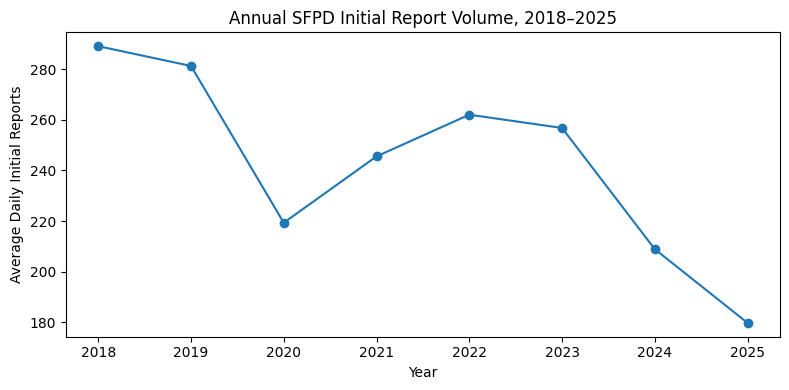

In [28]:
annual_pd = annual_reports.toPandas()

plt.figure(figsize=(8, 4))

plt.plot(
    annual_pd["incident_year"],
    annual_pd["avg_daily_reports"],
    marker="o"
)

plt.xlabel("Year")
plt.ylabel("Average Daily Initial Reports")
plt.title("Annual SFPD Initial Report Volume, 2018–2025")

plt.tight_layout()
plt.show()

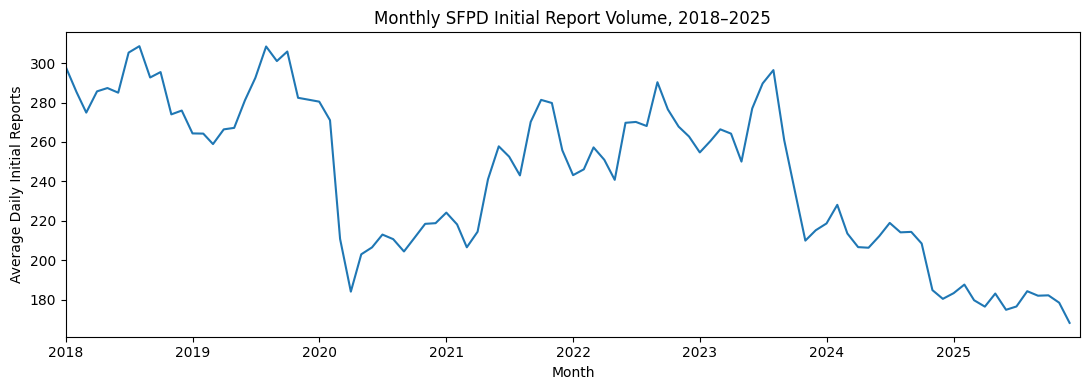

In [29]:
monthly_pd = monthly_reports.toPandas()

monthly_pd["year_month"] = pd.to_datetime(
    dict(
        year=monthly_pd["incident_year"],
        month=monthly_pd["incident_month"],
        day=1
    )
)

plt.figure(figsize=(11, 4))

plt.plot(
    monthly_pd["year_month"],
    monthly_pd["avg_daily_reports"]
)

plt.xlabel("Month")
plt.ylabel("Average Daily Initial Reports")
plt.title("Monthly SFPD Initial Report Volume, 2018–2025")

plt.xlim(
    pd.Timestamp("2018-01-01"),
    pd.Timestamp("2025-12-31")
)

plt.tight_layout()
plt.show()

In [30]:
month_seasonality = spark.sql("""
    WITH daily_counts AS (
        SELECT
            incident_date,
            incident_month,
            COUNT(*) AS daily_report_count
        FROM initial_reports
        GROUP BY incident_date, incident_month
    )

    SELECT
        incident_month,
        ROUND(AVG(daily_report_count), 2) AS mean_daily_reports,
        ROUND(STDDEV_SAMP(daily_report_count), 2) AS sd_daily_reports
    FROM daily_counts
    GROUP BY incident_month
    ORDER BY incident_month
""")

month_seasonality.show()

+--------------+------------------+----------------+
|incident_month|mean_daily_reports|sd_daily_reports|
+--------------+------------------+----------------+
|             1|            245.88|           47.44|
|             2|            245.21|           40.18|
|             3|            233.55|           44.28|
|             4|            231.14|           45.17|
|             5|            234.89|            42.4|
|             6|            245.56|            52.5|
|             7|            252.36|           49.28|
|             8|            254.24|           53.23|
|             9|            252.03|           49.66|
|            10|            249.64|           51.64|
|            11|            236.99|           49.42|
|            12|            232.35|           50.61|
+--------------+------------------+----------------+



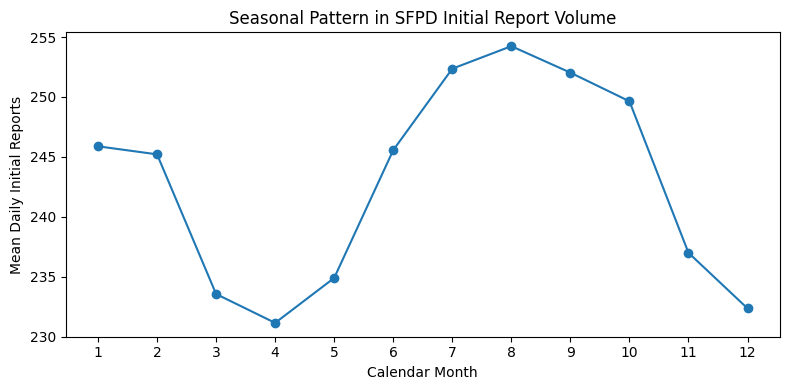

In [31]:
month_seasonality_pd = month_seasonality.toPandas()

plt.figure(figsize=(8, 4))

plt.plot(
    month_seasonality_pd["incident_month"],
    month_seasonality_pd["mean_daily_reports"],
    marker="o"
)

plt.xticks(range(1, 13))
plt.xlabel("Calendar Month")
plt.ylabel("Mean Daily Initial Reports")
plt.title("Seasonal Pattern in SFPD Initial Report Volume")

plt.tight_layout()
plt.show()

#### Key Observations

**Long-term shifts.** Initial-report volume declines sharply in early 2020, partially recovers during 2021–2023, and falls substantially again from late 2023 into 2024. Report volume remains comparatively low through 2025.

**Temporal structure.** Long-term level changes are substantially larger than pooled calendar-month differences, motivating explicit adjustment for temporal effects in later count models rather than attributing variation primarily to seasonality.

**Seasonality.** Across 2018–2025, mean daily initial-report volume is lowest in April and highest in August, with generally higher averages during July–October. These patterns are descriptive and are not interpreted as causal changes in underlying crime risk.

### 3.2 Incident Category Composition

In [32]:
category_coverage = spark.sql("""
    SELECT
        (SELECT COUNT(*) FROM initial_reports) AS total_initial_reports,
        COUNT(DISTINCT incident_id) AS categorized_initial_reports
    FROM initial_report_categories
""")

category_coverage = (
    category_coverage
    .withColumn(
        "uncategorized_initial_reports",
        F.col("total_initial_reports")
        - F.col("categorized_initial_reports")
    )
    .withColumn(
        "category_coverage_pct",
        F.round(
            100.0
            * F.col("categorized_initial_reports")
            / F.col("total_initial_reports"),
            2
        )
    )
)

category_coverage.show()

+---------------------+---------------------------+-----------------------------+---------------------+
|total_initial_reports|categorized_initial_reports|uncategorized_initial_reports|category_coverage_pct|
+---------------------+---------------------------+-----------------------------+---------------------+
|               709510|                     708946|                          564|                99.92|
+---------------------+---------------------------+-----------------------------+---------------------+



In [33]:
category_summary = spark.sql("""
    WITH total_reports AS (
        SELECT COUNT(*) AS n_reports
        FROM initial_reports
    )

    SELECT
        c.incident_category,
        COUNT(*) AS report_count,
        ROUND(
            100.0 * COUNT(*) / t.n_reports,
            2
        ) AS report_prevalence_pct
    FROM initial_report_categories c
    CROSS JOIN total_reports t
    GROUP BY
        c.incident_category,
        t.n_reports
    ORDER BY report_count DESC
""")

category_summary.show(15, truncate=False)

+-------------------+------------+---------------------+
|incident_category  |report_count|report_prevalence_pct|
+-------------------+------------+---------------------+
|Larceny Theft      |269822      |38.03                |
|Malicious Mischief |63848       |9.00                 |
|Other Miscellaneous|56153       |7.91                 |
|Assault            |54258       |7.65                 |
|Motor Vehicle Theft|50337       |7.09                 |
|Burglary           |44750       |6.31                 |
|Non-Criminal       |31830       |4.49                 |
|Lost Property      |29779       |4.20                 |
|Fraud              |28164       |3.97                 |
|Warrant            |23960       |3.38                 |
|Suspicious Occ     |19815       |2.79                 |
|Robbery            |18660       |2.63                 |
|Drug Offense       |18363       |2.59                 |
|Disorderly Conduct |16644       |2.35                 |
|Missing Person     |13510     

In [34]:
top_categories_pd = (
    category_summary
    .limit(12)
    .toPandas()
    .sort_values("report_prevalence_pct")
)

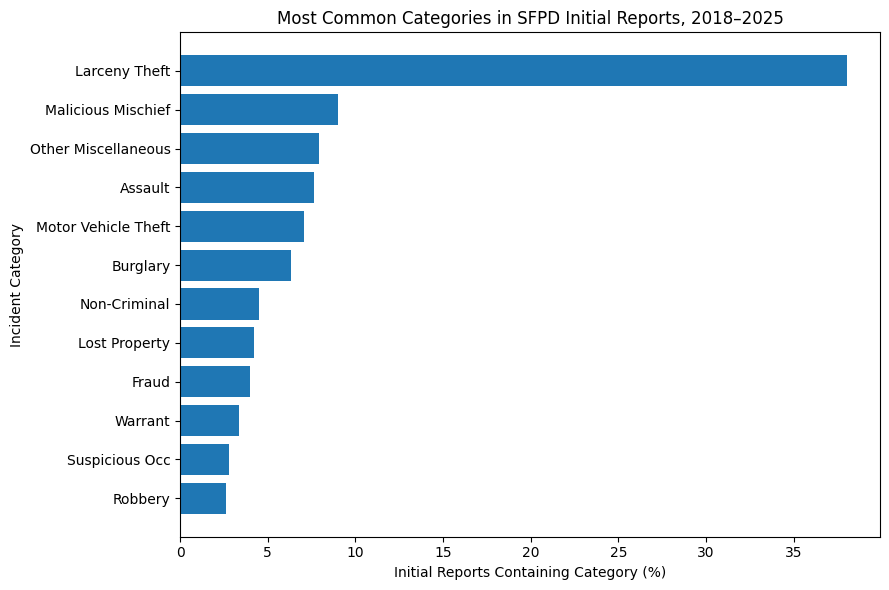

In [35]:
plt.figure(figsize=(9, 6))

plt.barh(
    top_categories_pd["incident_category"],
    top_categories_pd["report_prevalence_pct"]
)

plt.xlabel("Initial Reports Containing Category (%)")
plt.ylabel("Incident Category")
plt.title("Most Common Categories in SFPD Initial Reports, 2018–2025")

plt.tight_layout()
plt.show()

In [36]:
category_by_year = spark.sql("""
    WITH yearly_totals AS (
        SELECT
            incident_year,
            COUNT(*) AS total_initial_reports
        FROM initial_reports
        GROUP BY incident_year
    ),

    yearly_category_counts AS (
        SELECT
            r.incident_year,
            c.incident_category,
            COUNT(*) AS category_report_count
        FROM initial_report_categories c
        INNER JOIN initial_reports r
            ON c.incident_id = r.incident_id
        GROUP BY
            r.incident_year,
            c.incident_category
    )

    SELECT
        y.incident_year,
        y.incident_category,
        y.category_report_count,
        ROUND(
            100.0 * y.category_report_count
            / t.total_initial_reports,
            2
        ) AS report_prevalence_pct
    FROM yearly_category_counts y
    INNER JOIN yearly_totals t
        ON y.incident_year = t.incident_year
    ORDER BY
        y.incident_year,
        y.category_report_count DESC
""")

In [37]:
top_6_categories = (
    category_summary
    .limit(6)
    .select("incident_category")
    .rdd.flatMap(lambda x: x)
    .collect()
)

In [38]:
top_category_trends_pd = (
    category_by_year
    .filter(F.col("incident_category").isin(top_6_categories))
    .toPandas()
)

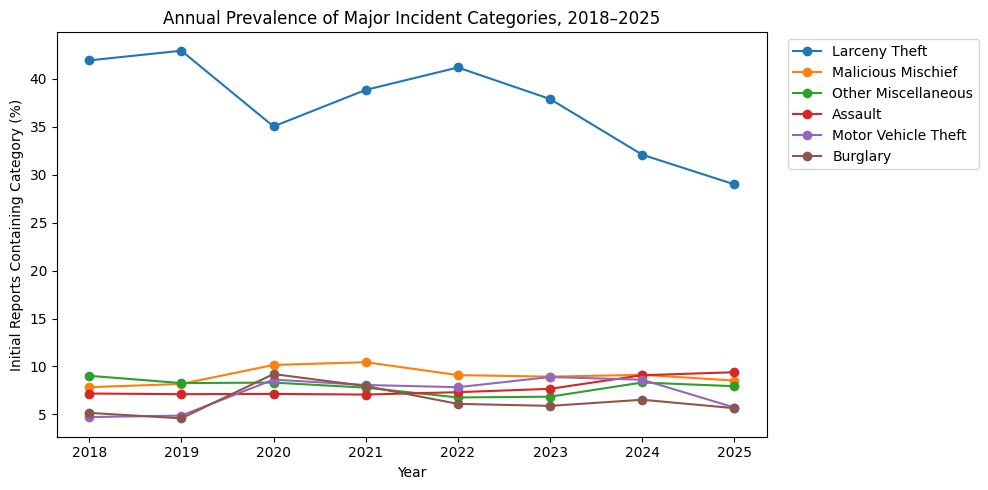

In [39]:
plt.figure(figsize=(10, 5))

for category in top_6_categories:
    subset = top_category_trends_pd[
        top_category_trends_pd["incident_category"] == category
    ]

    plt.plot(
        subset["incident_year"],
        subset["report_prevalence_pct"],
        marker="o",
        label=category
    )

plt.xlabel("Year")
plt.ylabel("Initial Reports Containing Category (%)")
plt.title("Annual Prevalence of Major Incident Categories, 2018–2025")
plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

#### Key Observations

**Category coverage.** Incident-category information is available for 99.92% of initial reports, leaving only 564 reports without a valid category during the 2018–2025 analysis period.

**Overall composition.** Larceny Theft is the most frequently represented category, appearing in 38.03% of initial reports, substantially exceeding the prevalence of any other individual category. Because reports may contain multiple categories, these percentages are non-exclusive and do not sum to 100%.

**Composition over time.** Larceny Theft remains the dominant category throughout the study period, but its prevalence declines notably after 2022, reaching approximately 29% of initial reports by 2025. Several major categories, including Malicious Mischief, Motor Vehicle Theft, and Burglary, increase in relative prevalence around 2020. Motor Vehicle Theft rises around 2020 and remains relatively high through 2024, while Malicious Mischief and Burglary rise around 2020 but decline again in later years.

**Interpretation.** Changes in category prevalence represent shifts in the composition of reported incidents rather than direct changes in category-specific crime rates; absolute report volume also changes substantially across years.

### 3.3 Geographic Distribution

In [40]:
geography_coverage = spark.sql("""
    SELECT
        COUNT(*) AS total_initial_reports,

        SUM(
            CASE
                WHEN police_district IS NULL
                  OR TRIM(police_district) = ''
                THEN 1 ELSE 0
            END
        ) AS missing_police_district,

        SUM(
            CASE
                WHEN analysis_neighborhood IS NULL
                  OR TRIM(analysis_neighborhood) = ''
                THEN 1 ELSE 0
            END
        ) AS missing_neighborhood,

        SUM(
            CASE
                WHEN latitude IS NULL OR longitude IS NULL
                THEN 1 ELSE 0
            END
        ) AS missing_coordinates

    FROM initial_reports
""")

geography_coverage.show()

+---------------------+-----------------------+--------------------+-------------------+
|total_initial_reports|missing_police_district|missing_neighborhood|missing_coordinates|
+---------------------+-----------------------+--------------------+-------------------+
|               709510|                      0|               35461|              35265|
+---------------------+-----------------------+--------------------+-------------------+



In [41]:
district_summary = spark.sql("""
    WITH total_reports AS (
        SELECT COUNT(*) AS total_count
        FROM initial_reports
    )

    SELECT
        r.police_district,
        COUNT(*) AS initial_report_count,
        ROUND(
            100.0 * COUNT(*) / t.total_count,
            2
        ) AS report_pct
    FROM initial_reports r
    CROSS JOIN total_reports t
    GROUP BY
        r.police_district,
        t.total_count
    ORDER BY initial_report_count DESC
""")

district_summary.show(20, truncate=False)

+---------------+--------------------+----------+
|police_district|initial_report_count|report_pct|
+---------------+--------------------+----------+
|Central        |107104              |15.10     |
|Northern       |100250              |14.13     |
|Mission        |89116               |12.56     |
|Southern       |87163               |12.28     |
|Tenderloin     |65325               |9.21      |
|Bayview        |59591               |8.40      |
|Ingleside      |55465               |7.82      |
|Taraval        |52971               |7.47      |
|Richmond       |46982               |6.62      |
|Park           |33519               |4.72      |
|Out of SF      |12024               |1.69      |
+---------------+--------------------+----------+



In [42]:
in_city_reports = (
    initial_report_level
    .filter(
        F.col("police_district").isNotNull()
        & (F.trim(F.col("police_district")) != "")
        & (F.col("police_district") != "Out of SF")
    )
)

print(f"In-city initial reports: {in_city_reports.count():,}")

in_city_reports.createOrReplaceTempView("in_city_reports")

In-city initial reports: 697,486


In [43]:
in_city_district_summary = spark.sql("""
    WITH total_reports AS (
        SELECT COUNT(*) AS total_count
        FROM in_city_reports
    )

    SELECT
        r.police_district,
        COUNT(*) AS initial_report_count,
        ROUND(
            100.0 * COUNT(*) / t.total_count,
            2
        ) AS in_city_report_pct
    FROM in_city_reports r
    CROSS JOIN total_reports t
    GROUP BY
        r.police_district,
        t.total_count
    ORDER BY initial_report_count DESC
""")

in_city_district_summary.show(truncate=False)

+---------------+--------------------+------------------+
|police_district|initial_report_count|in_city_report_pct|
+---------------+--------------------+------------------+
|Central        |107104              |15.36             |
|Northern       |100250              |14.37             |
|Mission        |89116               |12.78             |
|Southern       |87163               |12.50             |
|Tenderloin     |65325               |9.37              |
|Bayview        |59591               |8.54              |
|Ingleside      |55465               |7.95              |
|Taraval        |52971               |7.59              |
|Richmond       |46982               |6.74              |
|Park           |33519               |4.81              |
+---------------+--------------------+------------------+



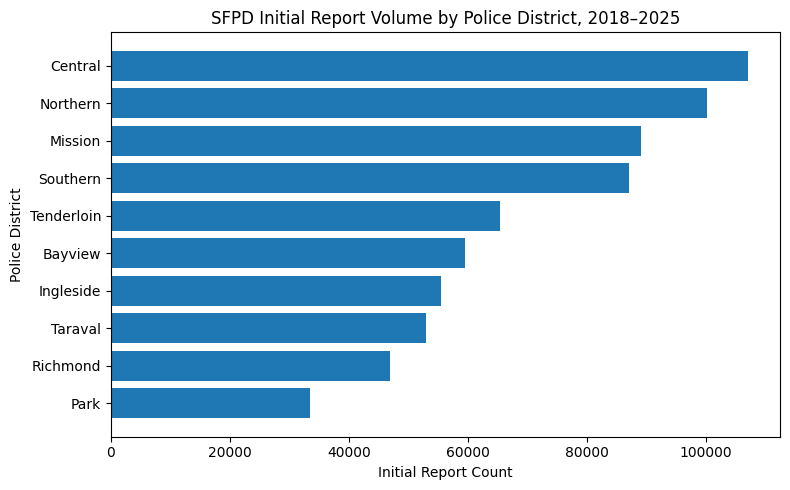

In [44]:
district_pd = (
    in_city_district_summary
    .toPandas()
    .sort_values("initial_report_count")
)

plt.figure(figsize=(8, 5))

plt.barh(
    district_pd["police_district"],
    district_pd["initial_report_count"]
)

plt.xlabel("Initial Report Count")
plt.ylabel("Police District")
plt.title("SFPD Initial Report Volume by Police District, 2018–2025")

plt.tight_layout()
plt.show()

In [45]:
district_by_year = spark.sql("""
    WITH yearly_district_counts AS (
        SELECT
            incident_year,
            police_district,
            COUNT(*) AS initial_report_count
        FROM in_city_reports
        GROUP BY
            incident_year,
            police_district
    ),

    yearly_totals AS (
        SELECT
            incident_year,
            COUNT(*) AS total_in_city_reports
        FROM in_city_reports
        GROUP BY incident_year
    )

    SELECT
        d.incident_year,
        d.police_district,
        d.initial_report_count,
        ROUND(
            100.0 * d.initial_report_count
            / y.total_in_city_reports,
            2
        ) AS yearly_report_pct
    FROM yearly_district_counts d
    INNER JOIN yearly_totals y
        ON d.incident_year = y.incident_year
    ORDER BY
        d.incident_year,
        d.initial_report_count DESC
""")

In [46]:
district_trends_pd = district_by_year.toPandas()

district_trends_pd["yearly_report_pct"] = pd.to_numeric(
    district_trends_pd["yearly_report_pct"]
)

district_order = (
    in_city_district_summary
    .select("police_district")
    .toPandas()["police_district"]
    .tolist()
)

district_pivot = (
    district_trends_pd
    .pivot(
        index="police_district",
        columns="incident_year",
        values="yearly_report_pct"
    )
    .reindex(district_order)
)

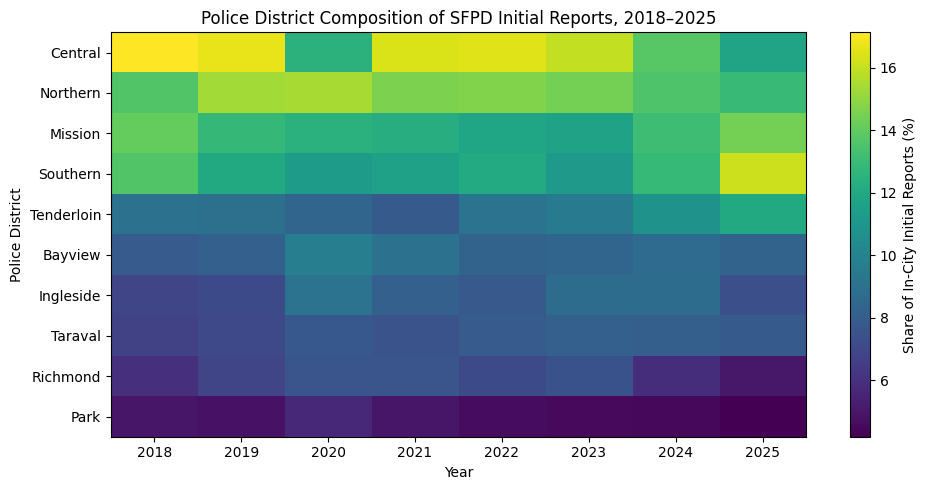

In [47]:
plt.figure(figsize=(10, 5))

image = plt.imshow(
    district_pivot.to_numpy(dtype=float),
    aspect="auto"
)

plt.colorbar(
    image,
    label="Share of In-City Initial Reports (%)"
)

plt.xticks(
    range(len(district_pivot.columns)),
    district_pivot.columns
)

plt.yticks(
    range(len(district_pivot.index)),
    district_pivot.index
)

plt.xlabel("Year")
plt.ylabel("Police District")
plt.title(
    "Police District Composition of SFPD Initial Reports, 2018–2025"
)

plt.tight_layout()
plt.show()

In [48]:
neighborhood_summary = spark.sql("""
    SELECT
        analysis_neighborhood,
        COUNT(*) AS initial_report_count
    FROM in_city_reports
    WHERE analysis_neighborhood IS NOT NULL
      AND TRIM(analysis_neighborhood) != ''
    GROUP BY analysis_neighborhood
    ORDER BY initial_report_count DESC
""")

neighborhood_summary.show(15, truncate=False)

+------------------------------+--------------------+
|analysis_neighborhood         |initial_report_count|
+------------------------------+--------------------+
|Mission                       |70395               |
|Tenderloin                    |63485               |
|South of Market               |58938               |
|Financial District/South Beach|47605               |
|Bayview Hunters Point         |38228               |
|Western Addition              |23488               |
|North Beach                   |22665               |
|Marina                        |20410               |
|Sunset/Parkside               |20210               |
|Hayes Valley                  |20178               |
|Nob Hill                      |20061               |
|Castro/Upper Market           |19437               |
|Russian Hill                  |16872               |
|Bernal Heights                |15071               |
|Outer Richmond                |14674               |
+---------------------------

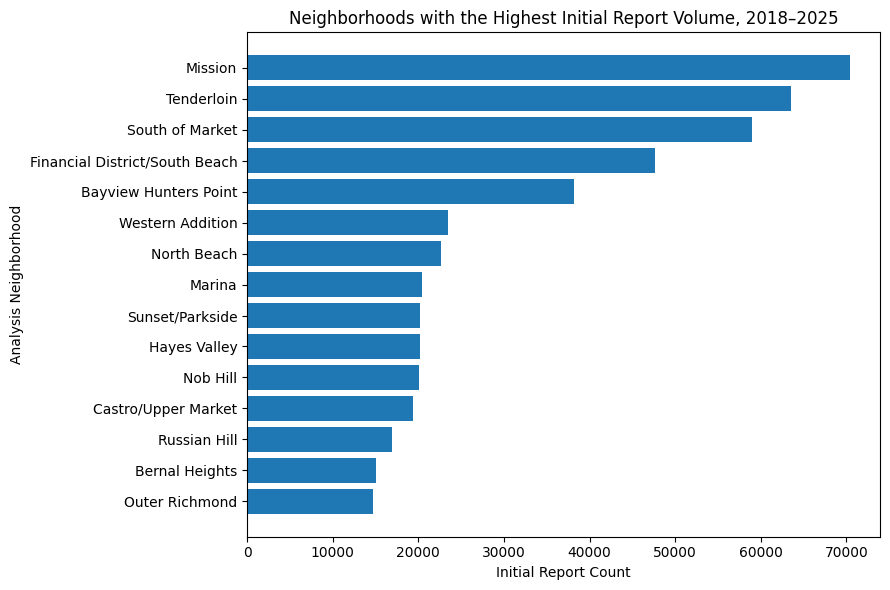

In [49]:
top_neighborhoods_pd = (
    neighborhood_summary
    .limit(15)
    .toPandas()
    .sort_values("initial_report_count")
)

plt.figure(figsize=(9, 6))

plt.barh(
    top_neighborhoods_pd["analysis_neighborhood"],
    top_neighborhoods_pd["initial_report_count"]
)

plt.xlabel("Initial Report Count")
plt.ylabel("Analysis Neighborhood")
plt.title("Neighborhoods with the Highest Initial Report Volume, 2018–2025")

plt.tight_layout()
plt.show()

#### Key Observations

**Geographic coverage.** Police-district information is available for all initial reports, while neighborhood and coordinate information are missing for roughly 5% of records. A further 12,024 reports are classified as `Out of SF` and are excluded from the in-city district analysis.

**Overall district distribution.** Central and Northern account for the largest shares of in-city initial-report volume over 2018–2025, followed by Mission and Southern. These differences represent report volume rather than population- or exposure-adjusted crime rates.

**Changes over time.** District composition is not constant across years. Central accounts for a smaller share of in-city reports in later years, while Southern and Tenderloin become relatively more prominent by 2025. These shifts motivate explicit adjustment for police district and temporal effects in later count models.

**Neighborhood concentration.** Mission, Tenderloin, South of Market, Financial District/South Beach, and Bayview Hunters Point have the highest cumulative initial-report volumes among neighborhoods with available geographic labels. These counts are descriptive and should not be interpreted as neighborhood-level risk estimates.

### 3.4 Weekly and Hourly Patterns

In [50]:
weekday_pattern = spark.sql("""
    WITH daily_counts AS (
        SELECT
            incident_date,
            incident_day_of_week,
            COUNT(*) AS daily_report_count
        FROM initial_reports
        GROUP BY
            incident_date,
            incident_day_of_week
    )

    SELECT
        incident_day_of_week,
        ROUND(AVG(daily_report_count), 2) AS mean_daily_reports,
        ROUND(STDDEV_SAMP(daily_report_count), 2) AS sd_daily_reports
    FROM daily_counts
    GROUP BY incident_day_of_week
    ORDER BY CASE incident_day_of_week
        WHEN 'Monday' THEN 1
        WHEN 'Tuesday' THEN 2
        WHEN 'Wednesday' THEN 3
        WHEN 'Thursday' THEN 4
        WHEN 'Friday' THEN 5
        WHEN 'Saturday' THEN 6
        WHEN 'Sunday' THEN 7
    END
""")

weekday_pattern.show()

+--------------------+------------------+----------------+
|incident_day_of_week|mean_daily_reports|sd_daily_reports|
+--------------------+------------------+----------------+
|              Monday|            238.78|           44.87|
|             Tuesday|            235.27|           43.39|
|           Wednesday|            247.79|            46.8|
|            Thursday|            239.82|           44.84|
|              Friday|            263.48|           50.87|
|            Saturday|            245.65|            51.1|
|              Sunday|            228.96|           51.69|
+--------------------+------------------+----------------+



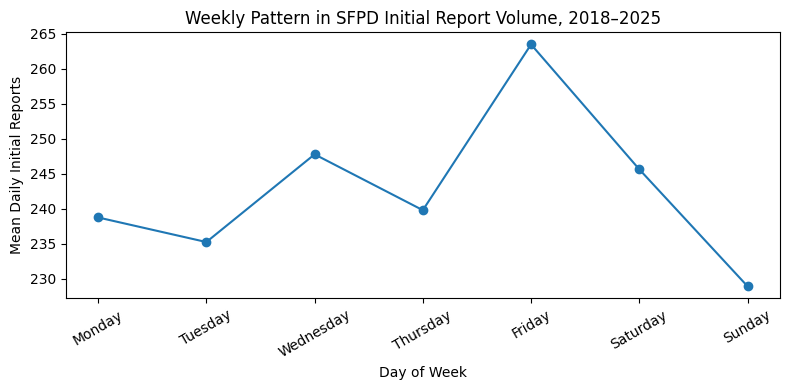

In [51]:
weekday_pd = weekday_pattern.toPandas()

plt.figure(figsize=(8, 4))

plt.plot(
    weekday_pd["incident_day_of_week"],
    weekday_pd["mean_daily_reports"],
    marker="o"
)

plt.xlabel("Day of Week")
plt.ylabel("Mean Daily Initial Reports")
plt.title("Weekly Pattern in SFPD Initial Report Volume, 2018–2025")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

In [52]:
hourly_pattern = spark.sql("""
    SELECT
        incident_hour,
        COUNT(*) AS initial_report_count,
        ROUND(
            100.0 * COUNT(*) /
            (SELECT COUNT(*) FROM initial_reports),
            2
        ) AS report_pct
    FROM initial_reports
    GROUP BY incident_hour
    ORDER BY incident_hour
""")

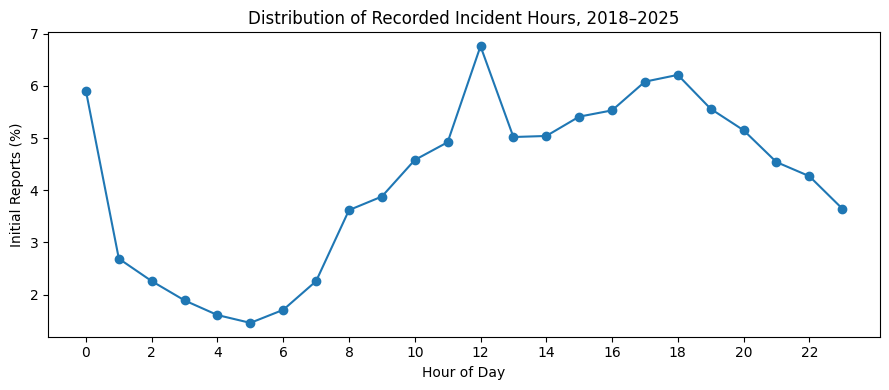

In [53]:
hourly_pd = hourly_pattern.toPandas()

plt.figure(figsize=(9, 4))

plt.plot(
    hourly_pd["incident_hour"],
    hourly_pd["report_pct"],
    marker="o"
)

plt.xticks(range(0, 24, 2))
plt.xlabel("Hour of Day")
plt.ylabel("Initial Reports (%)")
plt.title("Distribution of Recorded Incident Hours, 2018–2025")

plt.tight_layout()
plt.show()

In [54]:
minute_pattern = (
    initial_report_level
    .withColumn(
        "incident_minute",
        F.substring("incident_time", 4, 2).cast("int")
    )
    .groupBy("incident_minute")
    .agg(F.count("*").alias("report_count"))
    .orderBy(F.desc("report_count"))
)

minute_pattern.show(10)

+---------------+------------+
|incident_minute|report_count|
+---------------+------------+
|              0|      269941|
|             30|       95506|
|             45|       26682|
|             15|       25694|
|             20|       18162|
|             50|       17071|
|             40|       17033|
|             10|       15052|
|              5|        9769|
|             25|        9314|
+---------------+------------+
only showing top 10 rows


#### Key Observations

**Weekly pattern.** Mean daily initial-report volume varies across the week, reaching its highest level on Friday (263.48 reports per day) and its lowest on Sunday (228.96). The pattern supports accounting for day-of-week effects in later count models, although substantial day-to-day variability remains within each weekday.

**Recorded incident hours.** Reports are least concentrated during the early-morning hours and become more frequent during daytime and early evening, with visible peaks around noon and 17:00–18:00. These hourly patterns should be interpreted cautiously because the recorded times exhibit substantial rounding.

**Time heaping.** Recorded incident times are strongly concentrated at round-minute values: approximately 38% of initial reports have recorded incident times ending in `:00`, and another 13% end in `:30`. This suggests that many timestamps are approximate rather than minute-level measurements, limiting fine-grained interpretation of the hourly distribution.

## 4. Count Modeling of Daily District-Level Report Volume

### 4.1 Construction of the District-Day Count Panel

The modeled outcome is the number of Initial-report IDs associated with each incident date and police district. Thus, `daily_report_count` is indexed by recorded incident date rather than report-filing date.

In [55]:
calendar = spark.sql("""
    SELECT explode(
        sequence(
            to_date('2018-01-01'),
            to_date('2025-12-31'),
            interval 1 day
        )
    ) AS incident_date
""")

print(f"Calendar days: {calendar.count():,}")

Calendar days: 2,922


In [56]:
districts = (
    in_city_reports
    .select("police_district")
    .distinct()
    .orderBy("police_district")
)

districts.show(truncate=False)

print(f"Police districts: {districts.count()}")

+---------------+
|police_district|
+---------------+
|Bayview        |
|Central        |
|Ingleside      |
|Mission        |
|Northern       |
|Park           |
|Richmond       |
|Southern       |
|Taraval        |
|Tenderloin     |
+---------------+

Police districts: 10


In [57]:
district_day_grid = calendar.crossJoin(districts)

print(
    f"Complete district-day grid: "
    f"{district_day_grid.count():,} rows"
)

Complete district-day grid: 29,220 rows


In [58]:
daily_district_counts = (
    in_city_reports
    .groupBy(
        "incident_date",
        "police_district"
    )
    .agg(
        F.count("*").alias("daily_report_count")
    )
)

In [59]:
district_day_panel = (
    district_day_grid
    .join(
        daily_district_counts,
        on=["incident_date", "police_district"],
        how="left"
    )
    .fillna(
        {"daily_report_count": 0}
    )
)

In [60]:
district_day_panel = (
    district_day_panel
    .withColumn(
        "incident_year",
        F.year("incident_date")
    )
    .withColumn(
        "incident_month",
        F.month("incident_date")
    )
    .withColumn(
        "incident_day_of_week",
        F.date_format(
            "incident_date",
            "EEEE"
        )
    )
)

In [61]:
panel_validation = district_day_panel.select(
    F.count("*").alias("panel_rows"),
    F.countDistinct("incident_date").alias("unique_dates"),
    F.countDistinct("police_district").alias("unique_districts"),
    F.sum(
        (F.col("daily_report_count") == 0).cast("int")
    ).alias("zero_count_district_days"),
    F.min("daily_report_count").alias("min_daily_count"),
    F.max("daily_report_count").alias("max_daily_count"),
    F.round(
        F.avg("daily_report_count"),
        2
    ).alias("mean_daily_count"),
    F.round(
        F.stddev_samp("daily_report_count"),
        2
    ).alias("sd_daily_count")
)

panel_validation.show(truncate=False)

+----------+------------+----------------+------------------------+---------------+---------------+----------------+--------------+
|panel_rows|unique_dates|unique_districts|zero_count_district_days|min_daily_count|max_daily_count|mean_daily_count|sd_daily_count|
+----------+------------+----------------+------------------------+---------------+---------------+----------------+--------------+
|29220     |2922        |10              |0                       |1              |156            |23.87           |11.41         |
+----------+------------+----------------+------------------------+---------------+---------------+----------------+--------------+



In [62]:
district_day_coverage = (
    district_day_panel
    .groupBy("police_district")
    .agg(
        F.count("*").alias("days_in_panel"),
        F.sum(
            (F.col("daily_report_count") == 0).cast("int")
        ).alias("zero_count_days"),
        F.round(
            F.avg("daily_report_count"),
            2
        ).alias("mean_daily_reports"),
        F.round(
            F.stddev_samp("daily_report_count"),
            2
        ).alias("sd_daily_reports")
    )
    .orderBy(
        F.desc("mean_daily_reports")
    )
)

district_day_coverage.show(truncate=False)

+---------------+-------------+---------------+------------------+----------------+
|police_district|days_in_panel|zero_count_days|mean_daily_reports|sd_daily_reports|
+---------------+-------------+---------------+------------------+----------------+
|Central        |2922         |0              |36.65             |13.68           |
|Northern       |2922         |0              |34.31             |9.95            |
|Mission        |2922         |0              |30.5              |8.29            |
|Southern       |2922         |0              |29.83             |8.36            |
|Tenderloin     |2922         |0              |22.36             |7.58            |
|Bayview        |2922         |0              |20.39             |5.99            |
|Ingleside      |2922         |0              |18.98             |5.86            |
|Taraval        |2922         |0              |18.13             |5.52            |
|Richmond       |2922         |0              |16.08             |7.78      

In [63]:
model_df = (
    district_day_panel
    .orderBy(
        "incident_date",
        "police_district"
    )
    .toPandas()
)

model_df["incident_date"] = pd.to_datetime(
    model_df["incident_date"]
)

model_df.shape

(29220, 6)

#### Panel Validation

The completed analytical panel contains 29,220 observations, corresponding to all combinations of 2,922 calendar days and 10 in-city police districts from 2018 through 2025. Each district contributes the full 2,922-day observation window, and no district-day combination has zero Initial reports.

Daily report counts range from 1 to 156, with an overall mean of 23.87 and standard deviation of 11.41. Substantial differences in average daily volume across districts motivate explicit district effects in the subsequent count models.

### 4.2 Poisson Baseline and Overdispersion Diagnostics

In [64]:
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [65]:
observed_mean = model_df["daily_report_count"].mean()
observed_variance = model_df["daily_report_count"].var(ddof=1)
raw_variance_to_mean = observed_variance / observed_mean

print(f"Observed mean: {observed_mean:.2f}")
print(f"Observed variance: {observed_variance:.2f}")
print(f"Raw variance-to-mean ratio: {raw_variance_to_mean:.2f}")

Observed mean: 23.87
Observed variance: 130.12
Raw variance-to-mean ratio: 5.45


In [66]:
count_formula = """
daily_report_count ~
C(police_district, Treatment(reference="Central"))
+ C(incident_year, Treatment(reference=2018))
+ C(incident_month, Treatment(reference=1))
+ C(incident_day_of_week, Treatment(reference="Monday"))
"""

In [67]:
poisson_model = smf.glm(
    formula=count_formula,
    data=model_df,
    family=sm.families.Poisson()
).fit()

In [68]:
pearson_chi2 = np.sum(poisson_model.resid_pearson ** 2)
pearson_dispersion = pearson_chi2 / poisson_model.df_resid

deviance_dispersion = (
    poisson_model.deviance / poisson_model.df_resid
)

print(f"Pearson chi-square: {pearson_chi2:,.2f}")
print(f"Residual degrees of freedom: {poisson_model.df_resid:,.0f}")
print(f"Pearson dispersion: {pearson_dispersion:.3f}")
print(f"Deviance / df_resid: {deviance_dispersion:.3f}")

Pearson chi-square: 59,340.77
Residual degrees of freedom: 29,186
Pearson dispersion: 2.033
Deviance / df_resid: 1.919


#### Poisson Dispersion Assessment

The raw variance-to-mean ratio is 5.45, indicating substantial heterogeneity in district-day report counts. After controlling for police district, year, calendar month, and day of week, the Poisson model still yields a Pearson dispersion statistic of 2.03 and a deviance-to-residual-degrees-of-freedom ratio of 1.92.

Thus, observed variability remains materially larger than expected under the Poisson conditional mean-variance assumption. A Negative Binomial model is therefore considered to accommodate remaining overdispersion.

### 4.3 Negative Binomial Model

For police district $d$ on incident date $t$, let $Y_{dt}$ denote the daily Initial-report count. The primary model assumes

$$
Y_{dt} \sim \text{NB2}(\mu_{dt}, \alpha),
$$

with

$$
\log(\mu_{dt})
=
\beta_0
+
\beta_{\text{district}(d)}
+
\beta_{\text{year}(t)}
+
\beta_{\text{month}(t)}
+
\beta_{\text{weekday}(t)},
$$

and conditional variance

$$
\mathrm{Var}(Y_{dt}\mid X)
=
\mu_{dt}+\alpha\mu_{dt}^2.
$$

The reference categories are Central district, 2018, January, and Monday.

In [69]:
nb_model = smf.negativebinomial(
    formula=count_formula,
    data=model_df,
    loglike_method="nb2"
).fit(disp=False)

alpha_hat = nb_model.params["alpha"]

print(
    f"Converged: "
    f"{nb_model.mle_retvals['converged']}"
)

print(
    f"Estimated NB2 alpha: "
    f"{alpha_hat:.4f}"
)

Converged: True
Estimated NB2 alpha: 0.0382


In [70]:
model_comparison = pd.DataFrame(
    {
        "Model": [
            "Poisson",
            "Negative Binomial (NB2)"
        ],
        "Log-Likelihood": [
            poisson_model.llf,
            nb_model.llf
        ],
        "AIC": [
            poisson_model.aic,
            nb_model.aic
        ],
        "BIC": [
            poisson_model.bic_llf,
            nb_model.bic
        ]
    }
)

model_comparison

,Model,Log-Likelihood,AIC,BIC
0,Poisson,-99628.721562,199325.443124,199607.051819
1,Negative Binomial (NB2),-95521.783194,191113.566387,191403.457691


In [71]:
nb_mu = nb_model.predict(model_df)

nb_variance = (
    nb_mu
    + alpha_hat * nb_mu**2
)

nb_pearson_resid = (
    model_df["daily_report_count"] - nb_mu
) / np.sqrt(nb_variance)

nb_pearson_chi2 = np.sum(
    nb_pearson_resid**2
)

nb_df_resid = nb_model.df_resid

nb_pearson_dispersion = (
    nb_pearson_chi2 / nb_df_resid
)

print(
    f"NB2 Pearson dispersion: "
    f"{nb_pearson_dispersion:.3f}"
)

NB2 Pearson dispersion: 1.085


### 4.4 Interpretation of the Negative Binomial Model

The confidence intervals shown below are model-based NB2 intervals under the primary specification. Because subsequent residual diagnostics identify within-district temporal dependence, statistical significance is not emphasized; interpretation focuses primarily on effect direction and magnitude, with coefficient stability assessed separately using the GEE sensitivity analysis.

Because the model does not include a population or exposure offset, exponentiated coefficients are described as **expected count ratios** rather than population-standardized incidence rate ratios.

In [72]:
coef_table = pd.DataFrame({
    "term": nb_model.params.index,
    "coef": nb_model.params.values,
    "std_err": nb_model.bse.values,
    "p_value": nb_model.pvalues.values
})

conf_int = nb_model.conf_int()

coef_table["ci_lower"] = conf_int.iloc[:, 0].values
coef_table["ci_upper"] = conf_int.iloc[:, 1].values

coef_table["count_ratio"] = np.exp(
    coef_table["coef"]
)

coef_table["count_ratio_ci_lower"] = np.exp(
    coef_table["ci_lower"]
)

coef_table["count_ratio_ci_upper"] = np.exp(
    coef_table["ci_upper"]
)

coef_table = coef_table[
    ~coef_table["term"].isin(["Intercept", "alpha"])
].copy().reset_index(drop=True)

In [73]:
district_effects = (
    coef_table[
        coef_table["term"].str.contains("police_district")
    ]
    .copy()
)

district_effects["district"] = (
    district_effects["term"]
    .str.extract(r"\[T\.(.*?)\]")[0]
)

district_effects[
    [
        "district",
        "count_ratio",
        "count_ratio_ci_lower",
        "count_ratio_ci_upper"
    ]
].sort_values(
    "count_ratio",
    ascending=False
)

,district,count_ratio,count_ratio_ci_lower,count_ratio_ci_upper
3,Northern,0.943449,0.931027,0.956038
2,Mission,0.842163,0.830921,0.853557
6,Southern,0.825030,0.813986,0.836224
8,Tenderloin,0.619315,0.610695,0.628056
0,Bayview,0.562868,0.554924,0.570925
1,Ingleside,0.524435,0.516946,0.532032
7,Taraval,0.500864,0.493656,0.508177
5,Richmond,0.441711,0.435218,0.448301
4,Park,0.315749,0.310774,0.320804


In [74]:
district_plot = district_effects[
    [
        "district",
        "count_ratio",
        "count_ratio_ci_lower",
        "count_ratio_ci_upper"
    ]
].copy()

central_row = pd.DataFrame({
    "district": ["Central"],
    "count_ratio": [1.0],
    "count_ratio_ci_lower": [1.0],
    "count_ratio_ci_upper": [1.0]
})

district_plot = pd.concat(
    [central_row, district_plot],
    ignore_index=True
)

district_plot = district_plot.sort_values("count_ratio")

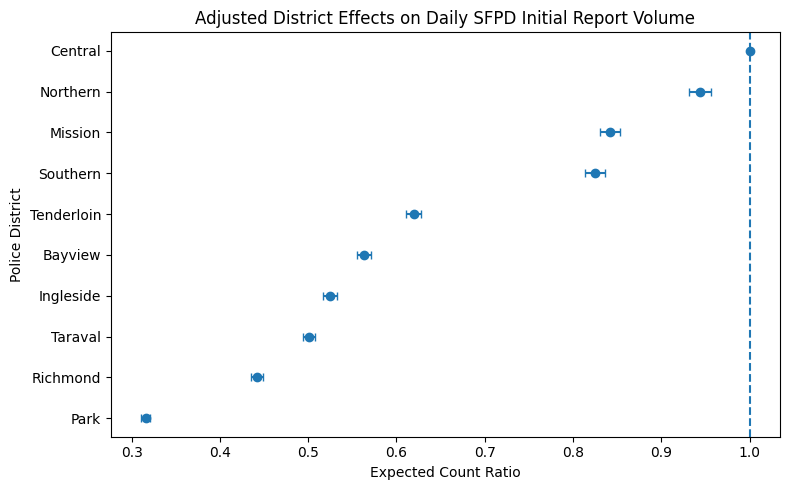

In [75]:
plt.figure(figsize=(8, 5))

xerr = np.vstack([
    district_plot["count_ratio"]
    - district_plot["count_ratio_ci_lower"],

    district_plot["count_ratio_ci_upper"]
    - district_plot["count_ratio"]
])

plt.errorbar(
    district_plot["count_ratio"],
    district_plot["district"],
    xerr=xerr,
    fmt="o",
    capsize=3
)

plt.axvline(1, linestyle="--")

plt.xlabel("Expected Count Ratio")
plt.ylabel("Police District")
plt.title(
    "Adjusted District Effects on Daily SFPD Initial Report Volume"
)

plt.tight_layout()
plt.show()

In [76]:
year_effects = coef_table[
    coef_table["term"].str.contains("incident_year")
].copy()

year_effects["year"] = (
    year_effects["term"]
    .str.extract(r"\[T\.(.*?)\]")[0]
    .astype(int)
)

year_effects[
    [
        "year",
        "count_ratio",
        "count_ratio_ci_lower",
        "count_ratio_ci_upper"
    ]
].sort_values("year")

,year,count_ratio,count_ratio_ci_lower,count_ratio_ci_upper
9,2019,0.975448,0.963179,0.987874
10,2020,0.778279,0.768168,0.788523
11,2021,0.862397,0.851365,0.873572
12,2022,0.914046,0.902447,0.925794
13,2023,0.897900,0.886472,0.909476
14,2024,0.729329,0.719782,0.739002
15,2025,0.625150,0.616765,0.633648


In [77]:
year_plot = year_effects[
    [
        "year",
        "count_ratio",
        "count_ratio_ci_lower",
        "count_ratio_ci_upper"
    ]
].copy()

reference_year = pd.DataFrame({
    "year": [2018],
    "count_ratio": [1.0],
    "count_ratio_ci_lower": [1.0],
    "count_ratio_ci_upper": [1.0]
})

year_plot = pd.concat(
    [reference_year, year_plot],
    ignore_index=True
).sort_values("year")

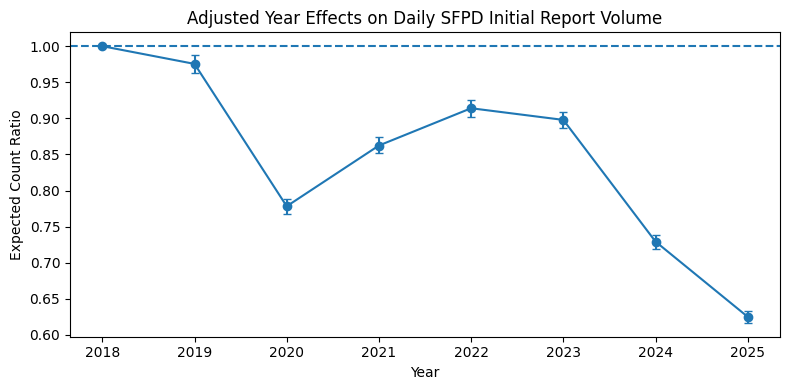

In [78]:
plt.figure(figsize=(8, 4))

plt.errorbar(
    year_plot["year"],
    year_plot["count_ratio"],
    yerr=np.vstack([
        year_plot["count_ratio"]
        - year_plot["count_ratio_ci_lower"],

        year_plot["count_ratio_ci_upper"]
        - year_plot["count_ratio"]
    ]),
    fmt="o-",
    capsize=3
)

plt.axhline(1, linestyle="--")

plt.xlabel("Year")
plt.ylabel("Expected Count Ratio")
plt.title(
    "Adjusted Year Effects on Daily SFPD Initial Report Volume"
)

plt.tight_layout()
plt.show()

In [79]:
month_effects = coef_table[
    coef_table["term"].str.contains("incident_month")
].copy()

month_effects["month"] = (
    month_effects["term"]
    .str.extract(r"\[T\.(.*?)\]")[0]
    .astype(int)
)

month_effects[
    [
        "month",
        "count_ratio",
        "count_ratio_ci_lower",
        "count_ratio_ci_upper"
    ]
].sort_values("month")

,month,count_ratio,count_ratio_ci_lower,count_ratio_ci_upper
16,2,1.000989,0.984748,1.017497
17,3,0.948826,0.933691,0.964205
18,4,0.940668,0.925517,0.956066
19,5,0.954406,0.939194,0.969865
20,6,0.994481,0.978590,1.010630
21,7,1.020647,1.004526,1.037027
22,8,1.029604,1.013355,1.046113
23,9,1.021365,1.005100,1.037894
24,10,1.012437,0.996425,1.028707
25,11,0.961368,0.945934,0.977054


In [80]:
month_plot = month_effects[
    [
        "month",
        "count_ratio",
        "count_ratio_ci_lower",
        "count_ratio_ci_upper"
    ]
].copy()

reference_month = pd.DataFrame({
    "month": [1],
    "count_ratio": [1.0],
    "count_ratio_ci_lower": [1.0],
    "count_ratio_ci_upper": [1.0]
})

month_plot = pd.concat(
    [reference_month, month_plot],
    ignore_index=True
).sort_values("month")

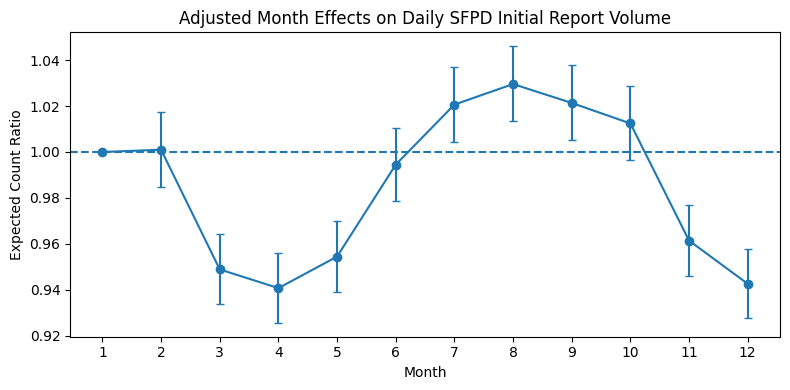

In [81]:
plt.figure(figsize=(8, 4))

plt.errorbar(
    month_plot["month"],
    month_plot["count_ratio"],
    yerr=np.vstack([
        month_plot["count_ratio"]
        - month_plot["count_ratio_ci_lower"],

        month_plot["count_ratio_ci_upper"]
        - month_plot["count_ratio"]
    ]),
    fmt="o-",
    capsize=3
)

plt.axhline(1, linestyle="--")

plt.xticks(range(1, 13))
plt.xlabel("Month")
plt.ylabel("Expected Count Ratio")
plt.title(
    "Adjusted Month Effects on Daily SFPD Initial Report Volume"
)

plt.tight_layout()
plt.show()

In [82]:
weekday_effects = coef_table[
    coef_table["term"].str.contains("incident_day_of_week")
].copy()

weekday_effects["weekday"] = (
    weekday_effects["term"]
    .str.extract(r"\[T\.(.*?)\]")[0]
)

In [83]:
weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

weekday_plot = weekday_effects[
    [
        "weekday",
        "count_ratio",
        "count_ratio_ci_lower",
        "count_ratio_ci_upper"
    ]
].copy()

reference_weekday = pd.DataFrame({
    "weekday": ["Monday"],
    "count_ratio": [1.0],
    "count_ratio_ci_lower": [1.0],
    "count_ratio_ci_upper": [1.0]
})

weekday_plot = pd.concat(
    [reference_weekday, weekday_plot],
    ignore_index=True
)

weekday_plot["weekday"] = pd.Categorical(
    weekday_plot["weekday"],
    categories=weekday_order,
    ordered=True
)

weekday_plot = weekday_plot.sort_values("weekday")

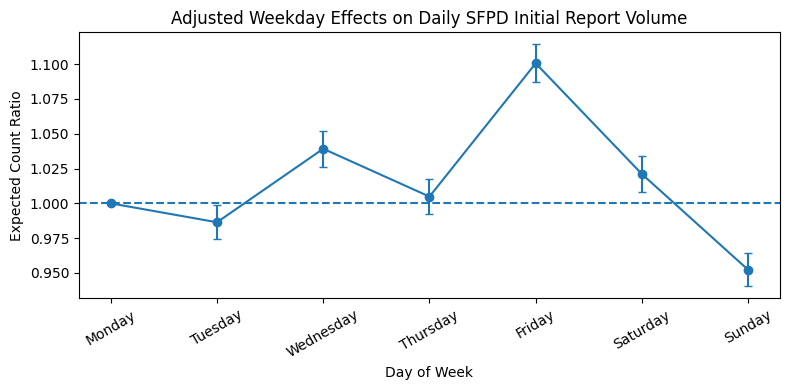

In [84]:
plt.figure(figsize=(8, 4))

plt.errorbar(
    weekday_plot["weekday"],
    weekday_plot["count_ratio"],
    yerr=np.vstack([
        weekday_plot["count_ratio"]
        - weekday_plot["count_ratio_ci_lower"],

        weekday_plot["count_ratio_ci_upper"]
        - weekday_plot["count_ratio"]
    ]),
    fmt="o-",
    capsize=3
)

plt.axhline(1, linestyle="--")

plt.xlabel("Day of Week")
plt.ylabel("Expected Count Ratio")
plt.title(
    "Adjusted Weekday Effects on Daily SFPD Initial Report Volume"
)

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

### 4.5 Model Diagnostics and Residual Dependence

In [85]:
diagnostic_df = model_df.copy()

diagnostic_df["fitted_count"] = nb_model.predict(model_df)
diagnostic_df["pearson_residual"] = nb_model.resid_pearson

diagnostic_summary = diagnostic_df[
    [
        "daily_report_count",
        "fitted_count",
        "pearson_residual"
    ]
].describe()

diagnostic_summary

,daily_report_count,fitted_count,pearson_residual
count,29220.000000,29220.000000,29220.000000
mean,23.870157,23.858642,0.000299
std,11.406912,8.793486,1.040956
min,1.000000,7.565589,-2.932576
25%,16.000000,17.117514,-0.694815
50%,22.000000,22.102494,-0.101424
75%,30.000000,31.047998,0.582408
max,156.000000,48.488955,25.225034


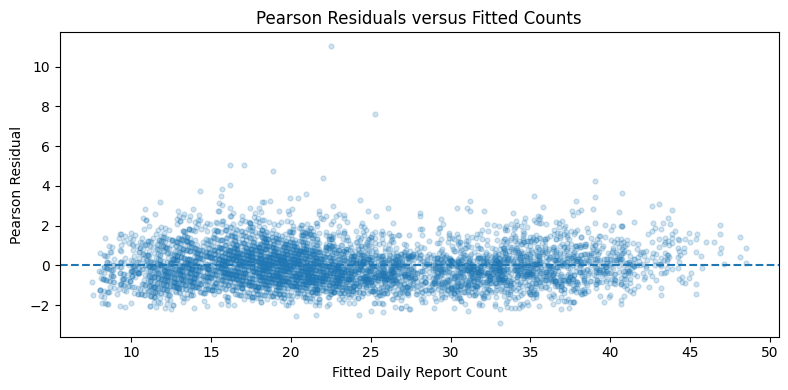

In [86]:
residual_plot_df = diagnostic_df.sample(
    n=min(5000, len(diagnostic_df)),
    random_state=42
)

plt.figure(figsize=(8, 4))

plt.scatter(
    residual_plot_df["fitted_count"],
    residual_plot_df["pearson_residual"],
    alpha=0.2,
    s=12
)

plt.axhline(0, linestyle="--")

plt.xlabel("Fitted Daily Report Count")
plt.ylabel("Pearson Residual")
plt.title("Pearson Residuals versus Fitted Counts")

plt.tight_layout()
plt.show()

In [87]:
extreme_residuals = (
    diagnostic_df
    .assign(
        abs_pearson_residual=lambda x:
        x["pearson_residual"].abs()
    )
    .sort_values(
        "abs_pearson_residual",
        ascending=False
    )
    .head(15)
    .copy()
)

extreme_residuals["fitted_count"] = (
    extreme_residuals["fitted_count"].round(2)
)

extreme_residuals["pearson_residual"] = (
    extreme_residuals["pearson_residual"].round(2)
)

extreme_residuals[
    [
        "incident_date",
        "police_district",
        "daily_report_count",
        "fitted_count",
        "pearson_residual"
    ]
].rename(
    columns={
        "incident_date": "date",
        "police_district": "district",
        "daily_report_count": "observed",
        "fitted_count": "fitted",
        "pearson_residual": "pearson_resid"
    }
)

,date,district,observed,fitted,pearson_resid
20496,2023-08-12,Richmond,156,17.84,25.23
24136,2024-08-10,Richmond,106,14.49,19.29
20506,2023-08-13,Richmond,115,16.64,18.86
16379,2022-06-26,Tenderloin,136,22.94,17.23
20486,2023-08-11,Richmond,107,19.23,15.20
23729,2024-06-30,Tenderloin,97,18.30,14.11
5459,2019-06-30,Tenderloin,107,24.48,11.99
20019,2023-06-25,Tenderloin,94,22.53,11.04
5866,2019-08-10,Richmond,70,19.38,8.72
24126,2024-08-09,Richmond,57,15.62,8.29


In [88]:
from statsmodels.tsa.stattools import acf

diagnostic_df = diagnostic_df.sort_values(
    ["police_district", "incident_date"]
)

max_lag = 30

district_acfs = []

for district, group in diagnostic_df.groupby("police_district"):
    residuals = group["pearson_residual"].to_numpy()

    district_acfs.append(
        acf(
            residuals,
            nlags=max_lag,
            fft=True
        )
    )

mean_residual_acf = np.mean(
    np.vstack(district_acfs),
    axis=0
)

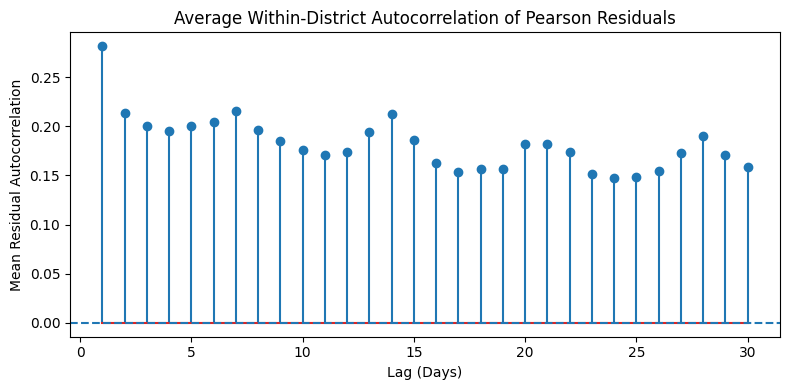

In [89]:
plt.figure(figsize=(8, 4))

plt.stem(
    range(1, max_lag + 1),
    mean_residual_acf[1:]
)

plt.axhline(0, linestyle="--")

plt.xlabel("Lag (Days)")
plt.ylabel("Mean Residual Autocorrelation")
plt.title(
    "Average Within-District Autocorrelation of Pearson Residuals"
)

plt.tight_layout()
plt.show()

#### Diagnostic Findings

The negative binomial model substantially improves the treatment of count dispersion, with Pearson residuals centered near zero and an overall residual scale close to one. Most district-day observations are reasonably captured by the fitted model, although several localized report-volume spikes produce unusually large positive residuals. The residual-versus-fitted plot also shows mild remaining structure across the fitted range, suggesting that the additive mean specification does not capture all district-day heterogeneity.

Residual autocorrelation remains positive within police districts, with the average lag-1 autocorrelation around 0.28 and persistent positive dependence across longer lags. Thus, the negative binomial specification addresses overdispersion but does not fully capture temporal dependence in daily report volume.

### 4.6 Temporal-Dependence Sensitivity Analysis

In [90]:
gee_df = (
    model_df
    .sort_values(
        ["police_district", "incident_date"]
    )
    .reset_index(drop=True)
)

gee_nb_family = sm.families.NegativeBinomial(
    alpha=alpha_hat
)

ar1_structure = sm.cov_struct.Autoregressive(
    grid=True
)

gee_ar1_model = smf.gee(
    formula=count_formula,
    groups="police_district",
    data=gee_df,
    family=gee_nb_family,
    cov_struct=ar1_structure
).fit()

In [91]:
gee_ar1_rho = gee_ar1_model.cov_struct.dep_params

print(f"NB2 alpha: {alpha_hat:.4f}")
print(f"GEE AR(1) working correlation: {gee_ar1_rho:.4f}")
print(f"Number of district clusters: {gee_df['police_district'].nunique()}")

NB2 alpha: 0.0382
GEE AR(1) working correlation: 0.3041
Number of district clusters: 10


In [92]:
comparison_terms = [
    term
    for term in gee_ar1_model.params.index
    if term != "Intercept"
]

nb_gee_comparison = pd.DataFrame({
    "term": comparison_terms,
    "NB2_count_ratio": np.exp(
        nb_model.params[comparison_terms].values
    ),
    "GEE_AR1_count_ratio": np.exp(
        gee_ar1_model.params[comparison_terms].values
    )
})

nb_gee_comparison["relative_count_ratio_difference_pct"] = (
    100
    * (
        nb_gee_comparison["GEE_AR1_count_ratio"]
        - nb_gee_comparison["NB2_count_ratio"]
    ).abs()
    / nb_gee_comparison["NB2_count_ratio"]
)

In [93]:
print(
    "Median relative count-ratio difference: "
    f"{nb_gee_comparison['relative_count_ratio_difference_pct'].median():.3f}%"
)

print(
    "Maximum relative count-ratio difference: "
    f"{nb_gee_comparison['relative_count_ratio_difference_pct'].max():.3f}%"
)

print(
    "Mean relative count-ratio difference: "
    f"{nb_gee_comparison['relative_count_ratio_difference_pct'].mean():.3f}%"
)

Median relative count-ratio difference: 0.029%
Maximum relative count-ratio difference: 0.899%
Mean relative count-ratio difference: 0.172%


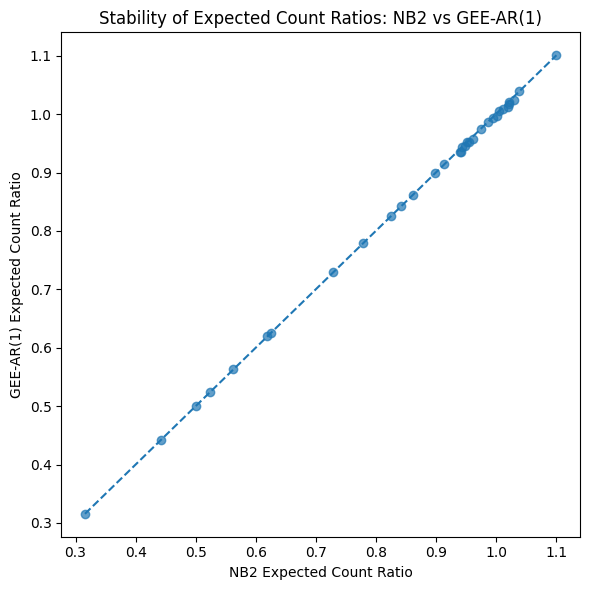

In [94]:
plot_df = nb_gee_comparison.copy()

lower = min(
    plot_df["NB2_count_ratio"].min(),
    plot_df["GEE_AR1_count_ratio"].min()
)

upper = max(
    plot_df["NB2_count_ratio"].max(),
    plot_df["GEE_AR1_count_ratio"].max()
)

plt.figure(figsize=(6, 6))

plt.scatter(
    plot_df["NB2_count_ratio"],
    plot_df["GEE_AR1_count_ratio"],
    alpha=0.7
)

plt.plot(
    [lower, upper],
    [lower, upper],
    linestyle="--"
)

plt.xlabel("NB2 Expected Count Ratio")
plt.ylabel("GEE-AR(1) Expected Count Ratio")
plt.title(
    "Stability of Expected Count Ratios: NB2 vs GEE-AR(1)"
)

plt.tight_layout()
plt.show()

#### Sensitivity Analysis

Residual diagnostics indicate persistent positive within-district temporal dependence, with an estimated GEE AR(1) working correlation of approximately 0.30. To assess whether this dependence materially affects the estimated covariate effects, the primary mean specification was re-estimated using GEE with district-level clustering, a Negative Binomial variance function, and an AR(1) working correlation structure. The Negative Binomial dispersion parameter was fixed at the NB2 estimate of $\hat{\alpha}=0.0382$.

The resulting expected count ratio estimates are highly stable across the two approaches. The median relative difference between NB2 and GEE-AR(1) expected count ratios is 0.029%, the mean difference is 0.172%, and the maximum difference is below 0.9%. Thus, although temporal dependence remains in the daily district-level counts, the substantive district, year, month, and weekday patterns are robust to explicitly accounting for first-order serial correlation.

Because only 10 district clusters are available, GEE robust standard errors and associated significance tests are not emphasized; the GEE model is used primarily as a coefficient-stability sensitivity analysis.

### 4.7 Modeling Summary

#### Model Selection

The raw district-day counts exhibit substantial overdispersion, with a variance-to-mean ratio of 5.45. After accounting for district, year, month, and weekday effects, the Poisson model still shows considerable residual overdispersion (Pearson dispersion = 2.03; deviance/df = 1.92).

The Negative Binomial (NB2) model provides a substantially better fit. The estimated dispersion parameter is $\alpha = 0.0382$, while the Pearson dispersion falls to 1.09. The NB2 model also improves both AIC and BIC relative to the Poisson baseline, supporting its use as the primary count model.

#### Adjusted Temporal and Geographic Patterns

After controlling simultaneously for district, year, month, and weekday, substantial differences in expected report volume remain across police districts and years. Year effects indicate a pronounced decline in 2020, partial recovery through 2022–2023, and substantially lower adjusted report volume in 2024–2025 relative to 2018.

Calendar-month effects are comparatively modest. Adjusted expected daily report counts are lowest around March–April and highest during July–September, while weekday effects show the highest adjusted report volume on Friday and the lowest on Sunday.

#### Residual Dependence and Sensitivity Analysis

Although the NB2 model largely resolves overdispersion, its Pearson residuals retain positive within-district temporal autocorrelation, including an average lag-1 correlation of approximately 0.28. This indicates that observations within a district are not fully independent over time.

As a sensitivity analysis, a Negative Binomial GEE with an AR(1) working correlation was therefore fitted by police district. The estimated working correlation is approximately 0.304. The estimated expected count ratios are highly consistent with the NB2 model: the median relative count-ratio difference is 0.029%, the mean difference is 0.172%, and the maximum difference is 0.899%.

#### Conclusion

Taken together, the diagnostics favor the Negative Binomial model over the Poisson baseline and show that the substantive district, temporal, seasonal, and weekday patterns are highly stable when within-district temporal dependence is incorporated. The NB2 model is therefore retained as the primary interpretable model, with the GEE analysis serving as a robustness check rather than a replacement for the main specification.

## 5. Integrated Findings, Limitations, and Conclusions

### 5.1 Integrated Findings

#### Long-Term Changes in Report Volume

The most pronounced pattern in the data is the long-term change in SFPD initial-report volume. Mean daily initial reports decline from 289.10 in 2018 to 219.32 in 2020, partially recover during 2021–2023, and then fall to 208.89 in 2024 and 179.75 in 2025.

The adjusted count model yields the same broad pattern. Holding police district, calendar month, and weekday constant, the expected daily report count in 2025 is approximately 62.5% of the corresponding 2018 level. The magnitude of these year-to-year changes is substantially larger than the estimated calendar-month effects.

#### Geographic Heterogeneity

Initial-report volume is unevenly distributed across San Francisco police districts. Central accounts for the largest share of in-city reports over 2018–2025, followed by Northern, Mission, and Southern. These geographic differences remain substantial after adjustment for year, month, and weekday.

The adjusted model should be interpreted as comparing expected report counts rather than population-standardized crime rates. For example, the expected daily count in Northern is approximately 94% of the Central reference level, while substantially lower count ratios are observed for several other districts.

#### Incident Composition

Larceny Theft is the dominant incident category, appearing in 38.03% of initial reports over the analysis period. Category composition also changes over time. Several major categories, including Malicious Mischief, Motor Vehicle Theft, and Burglary, increase in relative prevalence around 2020, although the persistence of these changes differs across categories. Motor Vehicle Theft remains relatively elevated through 2024, whereas the increases in Malicious Mischief and Burglary are less persistent.

Because individual reports may contain multiple incident categories, category prevalence represents the share of reports containing each category and is not mutually exclusive.

#### Seasonal and Weekly Structure

Calendar-month differences are present but modest relative to the long-term annual shifts. Descriptively, April has the lowest pooled mean daily report volume and August the highest. After adjustment, April has an expected count ratio of approximately 0.94 relative to January, while August has a ratio of approximately 1.03.

Weekly patterns are also consistent across descriptive and adjusted analyses. Friday has the highest mean daily report volume, while Sunday has the lowest. After adjustment for district, year, and month, Friday remains approximately 10% above the Monday reference level, while Sunday remains approximately 5% below it.

#### Model Robustness

The principal effect estimates are highly stable across the primary NB2 model and the GEE sensitivity specification. The Poisson baseline exhibits substantial residual overdispersion, motivating the Negative Binomial specification. NB2 reduces the Pearson dispersion from approximately 2.03 to 1.09 and substantially improves AIC and BIC.

Residual diagnostics nevertheless reveal positive within-district temporal dependence. A GEE sensitivity analysis using a Negative Binomial variance function and AR(1) working correlation estimates a correlation of approximately 0.30. Despite this dependence, the estimated count ratios are highly stable: the median relative difference between the NB2 and GEE estimates is 0.029%, the mean difference is 0.172%, and the maximum difference is below 0.9%.

### 5.2 Limitations and Interpretation Boundaries

#### Reported Incidents versus Underlying Crime

The dataset records police incident reports rather than the complete underlying incidence of crime. Changes in report volume may reflect changes in criminal activity, reporting behavior, police recording practices, online reporting systems, or other institutional processes. The results therefore describe SFPD reported incidents and should not be interpreted directly as changes in underlying crime risk.

#### Geographic Exposure

The district-level models do not include population, foot traffic, employment, tourism, or other measures of exposure. District coefficients therefore represent differences in expected report counts rather than per-capita or exposure-adjusted crime rates. High report volume in a district does not by itself imply that an individual faces greater crime risk there.

#### Observational Interpretation

The regression models estimate adjusted associations rather than causal effects. Year indicators, for example, summarize differences across calendar years after accounting for district, month, and weekday, but they do not identify the causes of those differences. Economic conditions, policy changes, mobility, major events, weather, policing practices, and other omitted factors may contribute to the observed temporal patterns.

#### Recorded Incident Time

The incident-time field exhibits substantial heaping at round clock times, particularly at minutes 00 and 30. Consequently, hourly patterns should be interpreted as patterns in recorded incident times rather than precise behavioral timing.

#### Residual Temporal Dependence

The Negative Binomial model substantially improves the count variance specification but does not eliminate within-district temporal dependence. The GEE sensitivity analysis indicates that the principal coefficient estimates are highly stable to an AR(1) working correlation structure; however, only 10 police-district clusters are available. GEE robust standard errors and significance tests are therefore not emphasized.

#### Data Coverage and Category Structure

Police-district information is complete for the primary analysis population, but neighborhood and coordinate information are missing for a small share of reports. Reports classified as `Out of SF` are excluded from the in-city geographic analysis. Incident categories are also non-exclusive because a single police report may contain multiple categories.

#### Geographic Data Harmonization

DataSF notes that incident locations reported before April 24, 2024 are currently mapped to a slightly different set of nearby intersections than incidents reported on or after that date. Analyses spanning this transition may therefore contain minor spatial reporting irregularities. Geographic changes around this period should consequently be interpreted with additional caution.

#### Additive Mean Structure

The primary count model uses additive district and calendar effects and does not include district-by-year interactions or district-specific temporal trends. The descriptive analysis indicates that district composition changes over time, so the adjusted district effects should be interpreted as average differences across the 2018–2025 study period rather than time-invariant district relationships.

### 5.3 Conclusion

This analysis identifies substantial and persistent temporal and geographic structure in SFPD initial-report volume from 2018 through 2025. Report volume falls sharply in 2020, partially recovers through 2022–2023, and declines again to substantially lower levels in 2024–2025. Geographic differences across police districts remain pronounced after adjustment, while calendar-month and weekday effects are present but considerably smaller than the long-term annual shifts.

The modeling workflow also demonstrates the importance of matching statistical assumptions to the structure of the data. A Poisson baseline is inadequate because of overdispersion, while the Negative Binomial model provides a substantially improved variance specification. Residual temporal dependence remains, but an AR(1) GEE sensitivity analysis produces nearly identical substantive effect estimates.

Taken together, the results support a consistent descriptive and model-adjusted account of variation in reported SFPD incident volume while emphasizing that these patterns describe police reports rather than causal changes in underlying crime risk. The analysis therefore provides a reproducible framework for studying large-scale public-safety administrative data using PySpark, Spark SQL, panel construction, count regression, model diagnostics, and sensitivity analysis.